In [6]:
import hoda
import tensorly as tl
import mne


mne.set_log_level('ERROR')
tl.get_backend()

'cupy'

In [7]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5

fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abbreviation of its code 'BNCI2014-009'. See moabb.datasets.base.is_abbrev for more information.


In [8]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [9]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(576, 16, 26)

In [10]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings

bttda = GreedyBTTDA(
    max_blocks=8,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
       
    ),
    verbose=True,
    extra_train_info=False,
    gs_params=dict(n_jobs=-1),
    
)
%env PYTHONWARNINGS=ignore
%prun bttda.fit(X,y, X_test=X, y_test=y)

env: PYTHONWARNINGS=ignore
Fitting block 1/8...
Fitting block 2/8...
Fitting block 3/8...
Fitting block 4/8...
 

         405398 function calls (388811 primitive calls) in 28.695 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     2593   26.628    0.010   26.628    0.010 {built-in method time.sleep}
        4    0.408    0.102    0.408    0.102 {built-in method cupy_backends.cuda.libs.nvrtc.compileProgram}
      286    0.151    0.001    0.230    0.001 cov.py:69(ledoit_wolf_shrinkage)
       12    0.110    0.009    0.111    0.009 {built-in method posix.fork}
     2005    0.110    0.000    0.111    0.000 {built-in method cupy._core.core.array}
      588    0.106    0.000    0.484    0.001 cov.py:17(mode_scatter)
      278    0.082    0.000    0.587    0.002 util.py:20(trunc_eigh)
     1994    0.067    0.000    0.068    0.000 {method 'sum' of 'cupy._core.core._ndarray_base' objects}
      278    0.055    0.000    0.055    0.000 {built-in method cupy_backends.cuda.libs.cusolver.xsyevd}
        4    0.048    0.012    1.420    0.355 hoda.p

In [11]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank,val_score,test_score
0,1,"(2, 2)",0.968777,0.986458
1,2,"(1, 1)",0.983169,0.991623
2,3,"(1, 1)",0.988054,0.991819


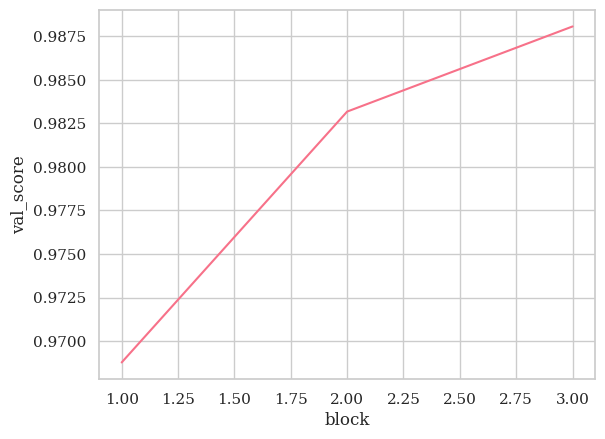

<Axes: xlabel='block', ylabel='test_score'>

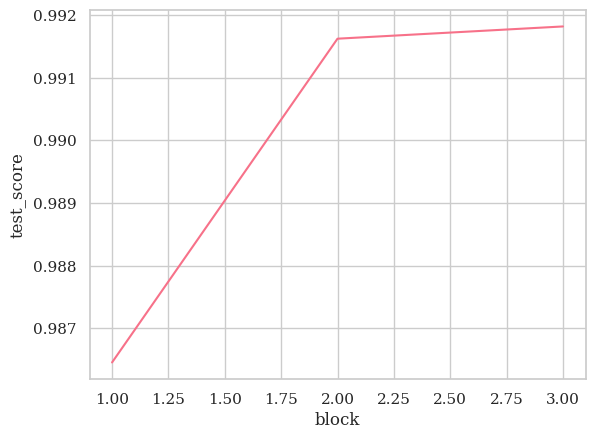

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

n_samples = X.shape[0]
sns.lineplot(data=df, x='block', y='val_score')
plt.show()
sns.lineplot(data=df, x='block', y='test_score')

In [13]:
Xt = bttda.transform(X)

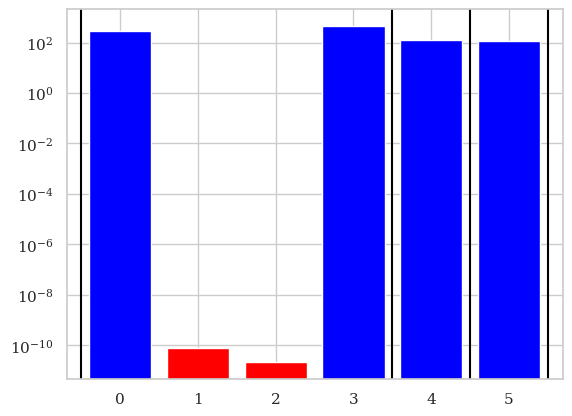

In [14]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.05/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b,block in enumerate(bttda.blocks_):
    n_params+=math.prod(block.rank_)
    plt.axvline(n_params-.5, color='black')

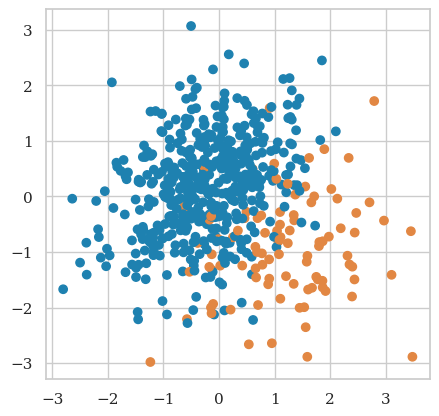

In [15]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [16]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]), units=dict(eeg=None))
joint_args=dict(ts_args=ts_args)

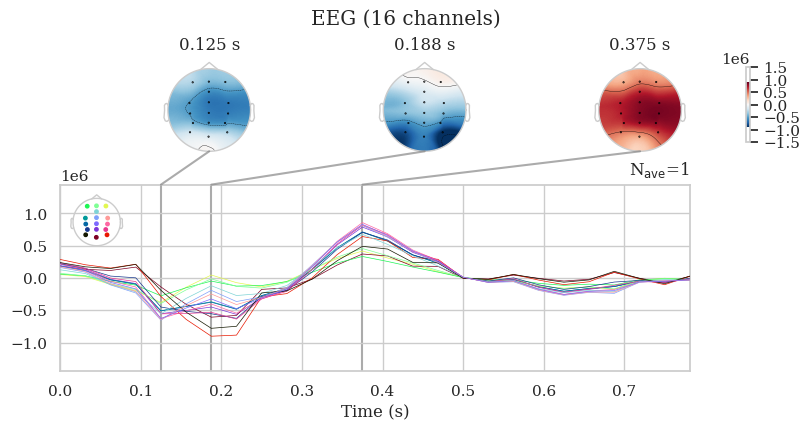

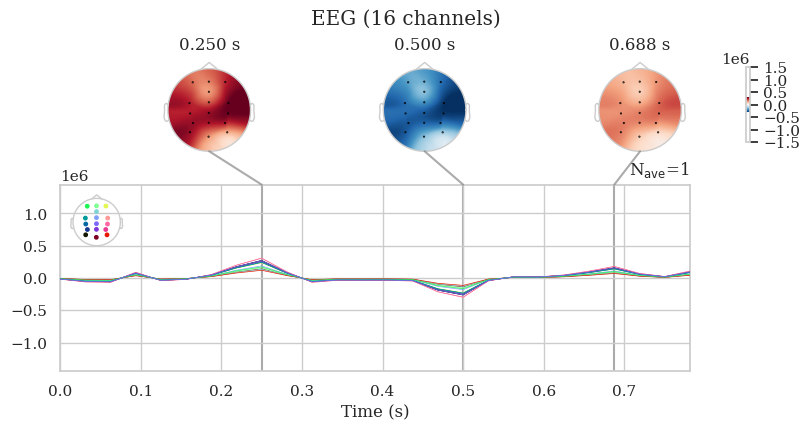

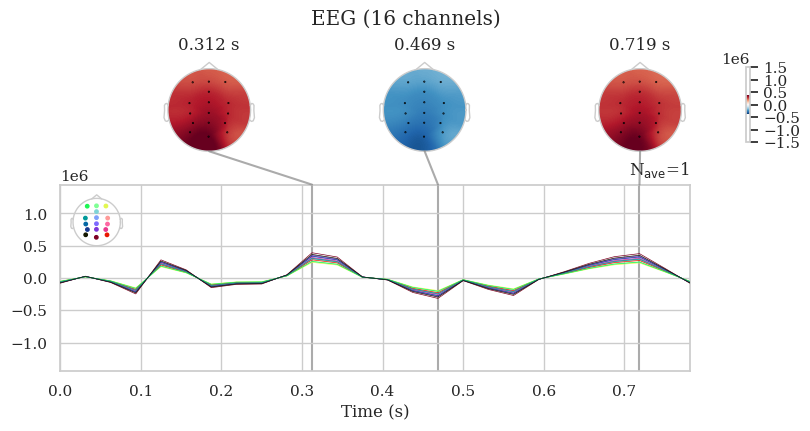

In [17]:
from mne import EvokedArray
for b in bttda.blocks_[:10]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

In [18]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

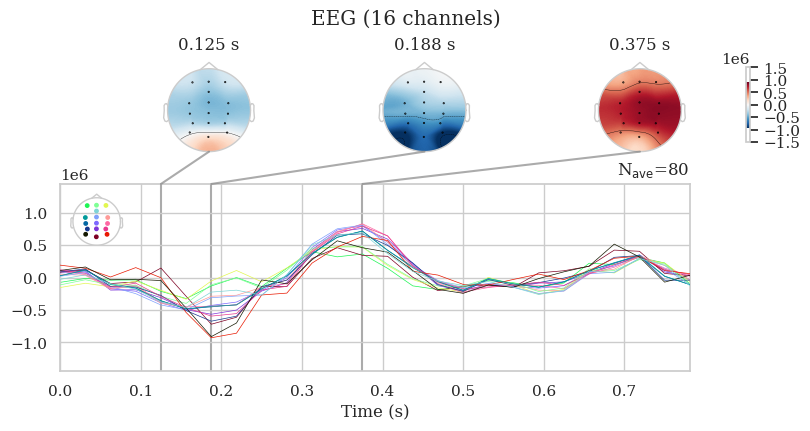

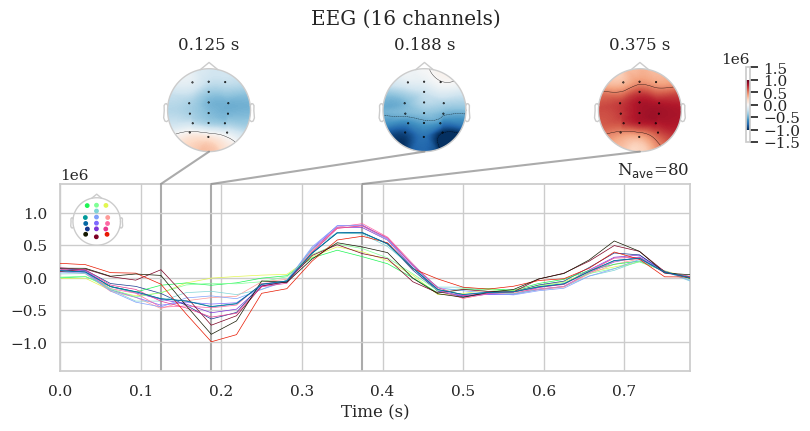

In [19]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


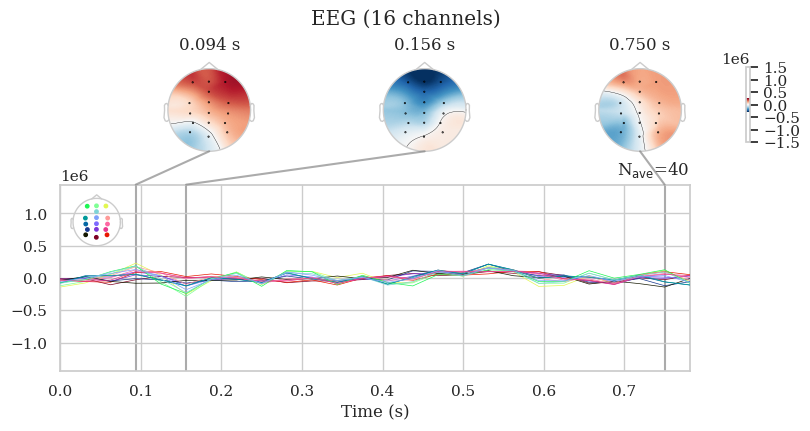

In [20]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)